# Next media batch: a narrated walkthrough

This notebook follows the memo (`reports/memo.pdf`) in order and shows the evidence behind each step. It reads the tables and figures that `run_all.sh` writes, and refits the main Gaussian process (GP) once so you can see the model directly. All selection logic lives in `scripts/`.

**Question.** Which 3 to 5 media formulations should the lab run next, balancing viability, cost, uncertainty, noise, feasibility and batch size?

**Answer.** Four new blends of DMEM-10, RPMI-10, X-VIVO 15 and AR5, plus a same-plate re-run of the best historical blend, E19.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
pd.set_option('display.width', 160, 'display.max_columns', 30)
fig = lambda name, width=720: display(Image(filename=str(ROOT / 'reports/figures' / name), width=width))

## 1. The data

24 blends from Narayanan et al. (2025), run in four rounds of six, with viability at 72 hours. Fractions are volume shares that sum to 1.

In [2]:
data = pd.read_csv(ROOT / 'data/processed/pbmc_analysis.csv')
cols = ['formulation_id', 'round', 'dmem_fraction', 'rpmi_10_fraction', 'xvivo_fraction', 'ar5_fraction',
        'n_readings', 'viability_mean_pct', 'viability_sd_pct_points', 'blend_cost_per_litre']
data[cols].round(3)

,formulation_id,round,dmem_fraction,rpmi_10_fraction,xvivo_fraction,ar5_fraction,n_readings,viability_mean_pct,viability_sd_pct_points,blend_cost_per_litre
0,PBMC-E01,0,0.003,0.385,0.176,0.436,5,60.583,9.400,176.167
1,PBMC-E02,0,0.051,0.233,0.380,0.335,4,6.542,1.477,178.070
2,PBMC-E03,0,0.171,0.199,0.000,0.630,5,40.400,12.735,178.486
3,PBMC-E04,0,0.081,0.001,0.522,0.397,5,40.267,3.397,180.978
4,PBMC-E05,0,0.545,0.193,0.008,0.254,5,41.733,11.309,178.518
5,PBMC-E06,0,0.001,0.678,0.210,0.111,5,50.383,6.549,172.493
6,PBMC-E07,1,0.291,0.318,0.338,0.052,3,48.028,12.711,176.973
7,PBMC-E08,1,0.329,0.281,0.084,0.305,3,48.639,3.952,177.434
8,PBMC-E09,1,0.605,0.198,0.143,0.054,5,46.900,12.913,178.446
9,PBMC-E10,1,0.244,0.393,0.002,0.361,5,48.150,5.564,176.041


## 2. What the data says

Round 3 beat every earlier round, but all six round-3 blends sit at about 44% DMEM, so a recipe effect and a batch effect look the same. E10 and E14 are 2.6% of volume apart and 40.6 points apart in viability.

,count,mean,min,max
round,,,,
0,6,39.98,6.54,60.58
1,6,50.65,44.12,68.05
2,6,42.29,7.52,56.46
3,6,72.65,67.40,81.00


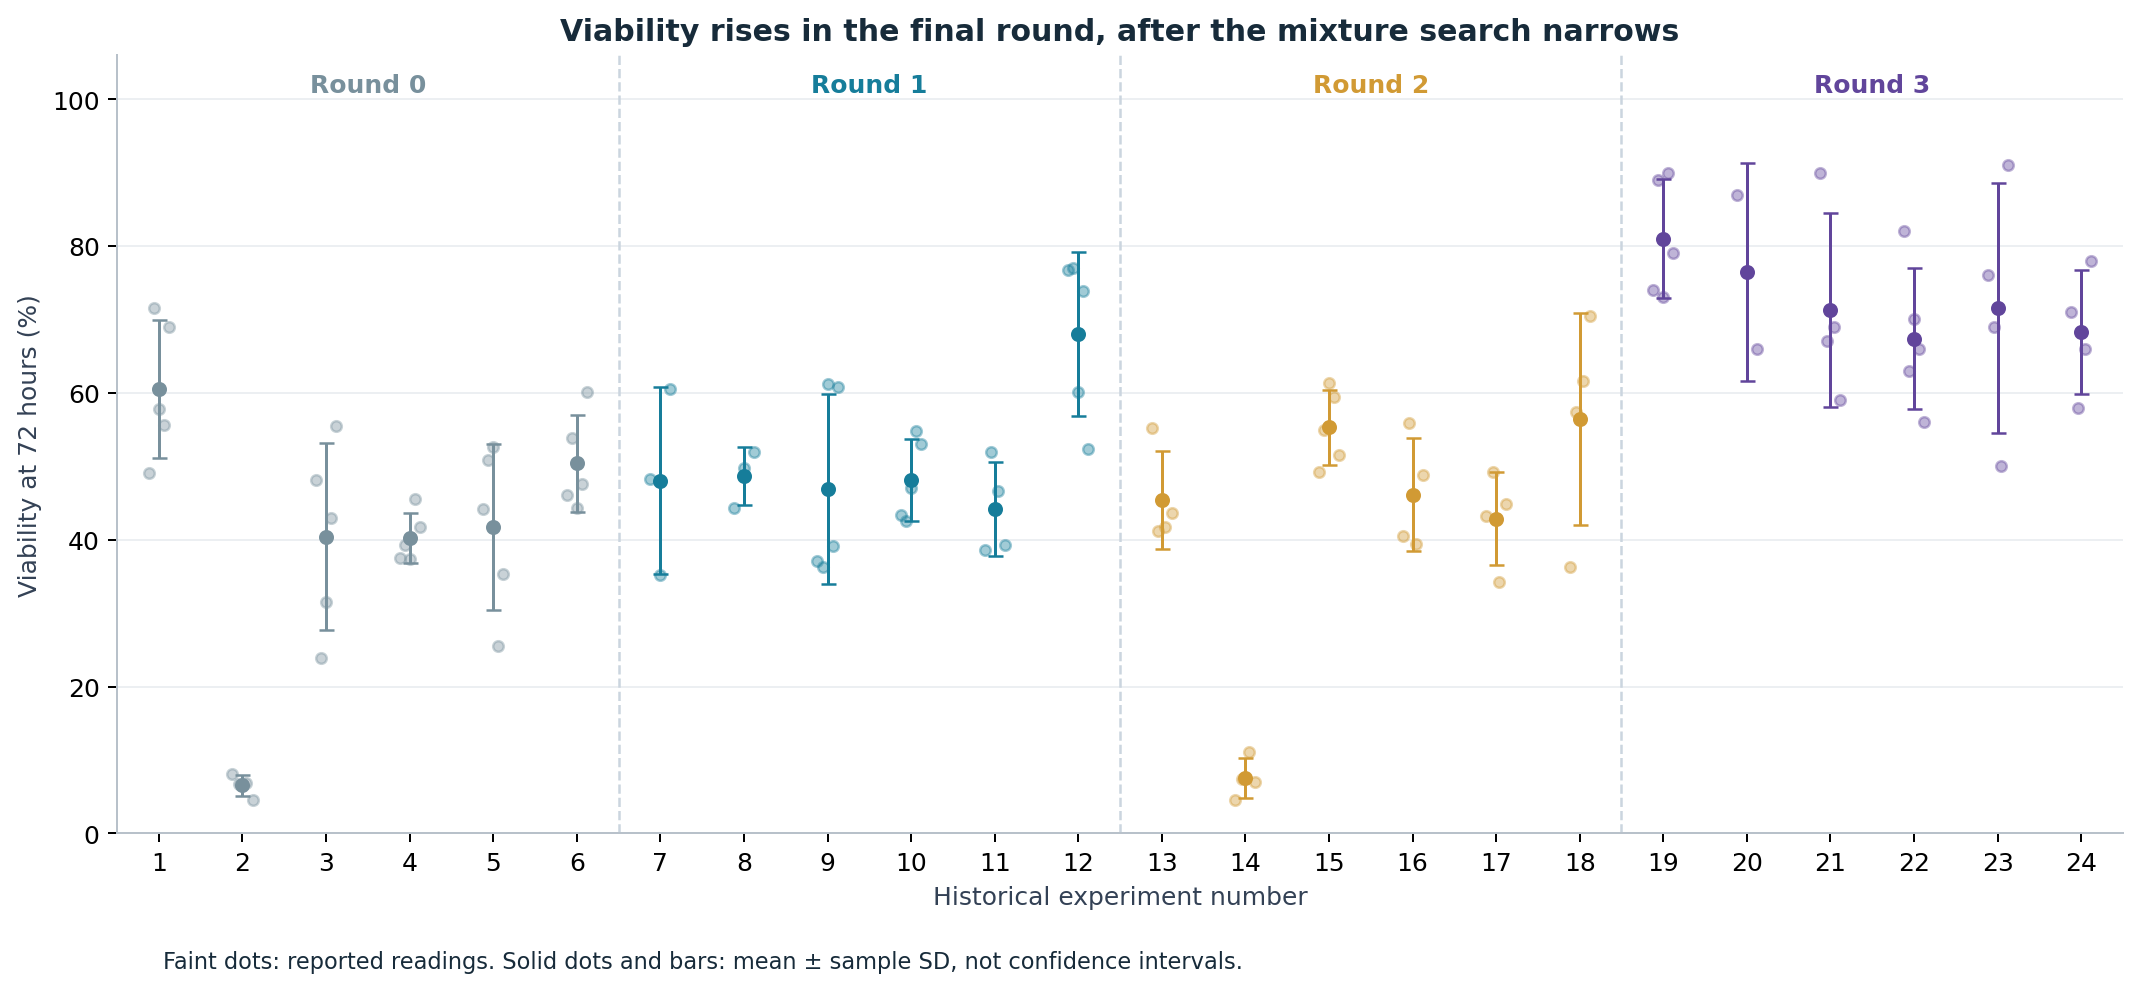

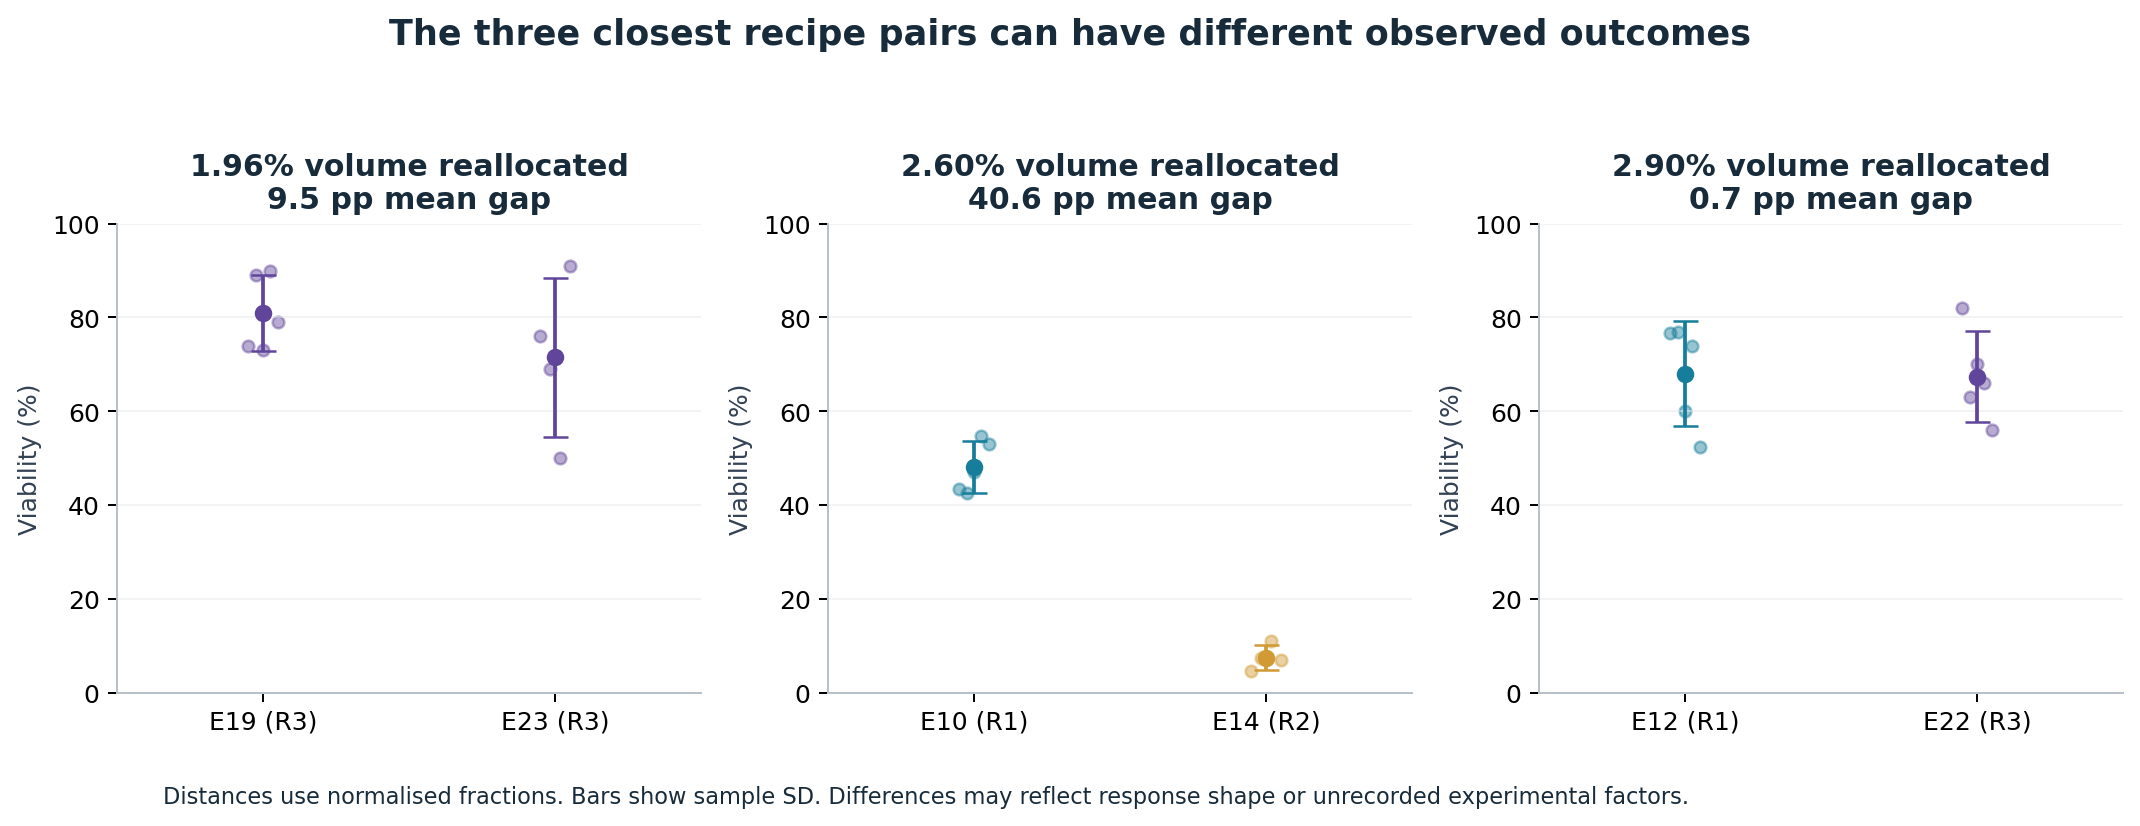

In [3]:
display(data.groupby('round')['viability_mean_pct'].agg(['count', 'mean', 'min', 'max']).round(2))
fig('01_viability_by_experiment.png')
fig('05_nearest_recipe_pairs.png')

## 3. Cost

Prices are provisional (see `data/inputs/price_sources.csv`). The cost rule: a new blend may cost no more per litre than E19 under the same price scenario. Nine scenarios vary the two least certain prices, FBS and AR5.

In [4]:
display(pd.read_csv(ROOT / 'data/inputs/component_costs.csv')[['component_id', 'price_per_litre', 'currency', 'price_basis']])
pd.read_csv(ROOT / 'reports/tables/cost_rule_feasibility.csv')

,component_id,price_per_litre,currency,price_basis
0,dmem,180.89,EUR,estimate
1,rpmi_10,168.45,EUR,estimate
2,xvivo,181.00,EUR,observed
3,ar5,181.00,EUR,hypothetical


,scenario,ceiling_eur_per_litre,grid_points,feasible_grid_share,historical_feasible,min_rpmi_share_on_feasible_grid
0,base,178.43,176851,0.503,15,0.2
1,fbs_x0.5_ar5_x1.0,134.93,176851,0.316,14,0.0
2,fbs_x0.5_ar5_x1.5,149.12,176851,0.317,12,0.0
3,fbs_x0.5_ar5_x2.02,163.89,176851,0.342,10,0.0
4,fbs_x1.0_ar5_x1.0,178.43,176851,0.503,15,0.2
5,fbs_x1.0_ar5_x1.5,192.63,176851,0.423,8,0.0
6,fbs_x1.0_ar5_x2.02,207.39,176851,0.414,8,0.0
7,fbs_x1.5_ar5_x1.0,221.93,176851,0.745,14,0.0
8,fbs_x1.5_ar5_x1.5,236.13,176851,0.504,7,0.0
9,fbs_x1.5_ar5_x2.02,250.89,176851,0.466,8,0.0


## 4. Model comparison

Leave-one-out on all 24 blends is the primary view. The forward-round test (train on earlier rounds, predict the next) is the honest one, and every model fails it on round 3.

,model,rmse,spearman,coverage_80,nlpd
0,"GP, pooled noise",16.766,0.606,0.792,5.934
1,"GP, per-recipe SEM noise",20.112,0.542,0.750,5.607
2,Scheffe quadratic (Bayesian ridge),19.718,-0.012,0.750,4.485
3,Random forest,16.323,0.554,0.792,5.130
4,Mean only (baseline),18.766,NaN,0.833,4.435


,model,test_round,rmse,bias,spearman,coverage_80
0,"GP, pooled noise",1,25.564,14.366,0.257,0.167
1,"GP, pooled noise",2,18.726,-3.060,-0.314,0.833
2,"GP, pooled noise",3,27.139,26.764,0.257,0.000
3,"GP, per-recipe SEM noise",1,19.945,15.722,0.771,0.500
4,"GP, per-recipe SEM noise",2,17.307,-6.052,0.200,0.833
5,"GP, per-recipe SEM noise",3,24.326,22.277,-0.657,1.000
6,Scheffe quadratic (Bayesian ridge),1,19.323,17.655,0.657,0.833
7,Scheffe quadratic (Bayesian ridge),2,18.218,-4.547,0.143,0.833
8,Scheffe quadratic (Bayesian ridge),3,29.805,29.089,-0.600,0.167
9,Random forest,1,13.786,12.304,0.714,0.833


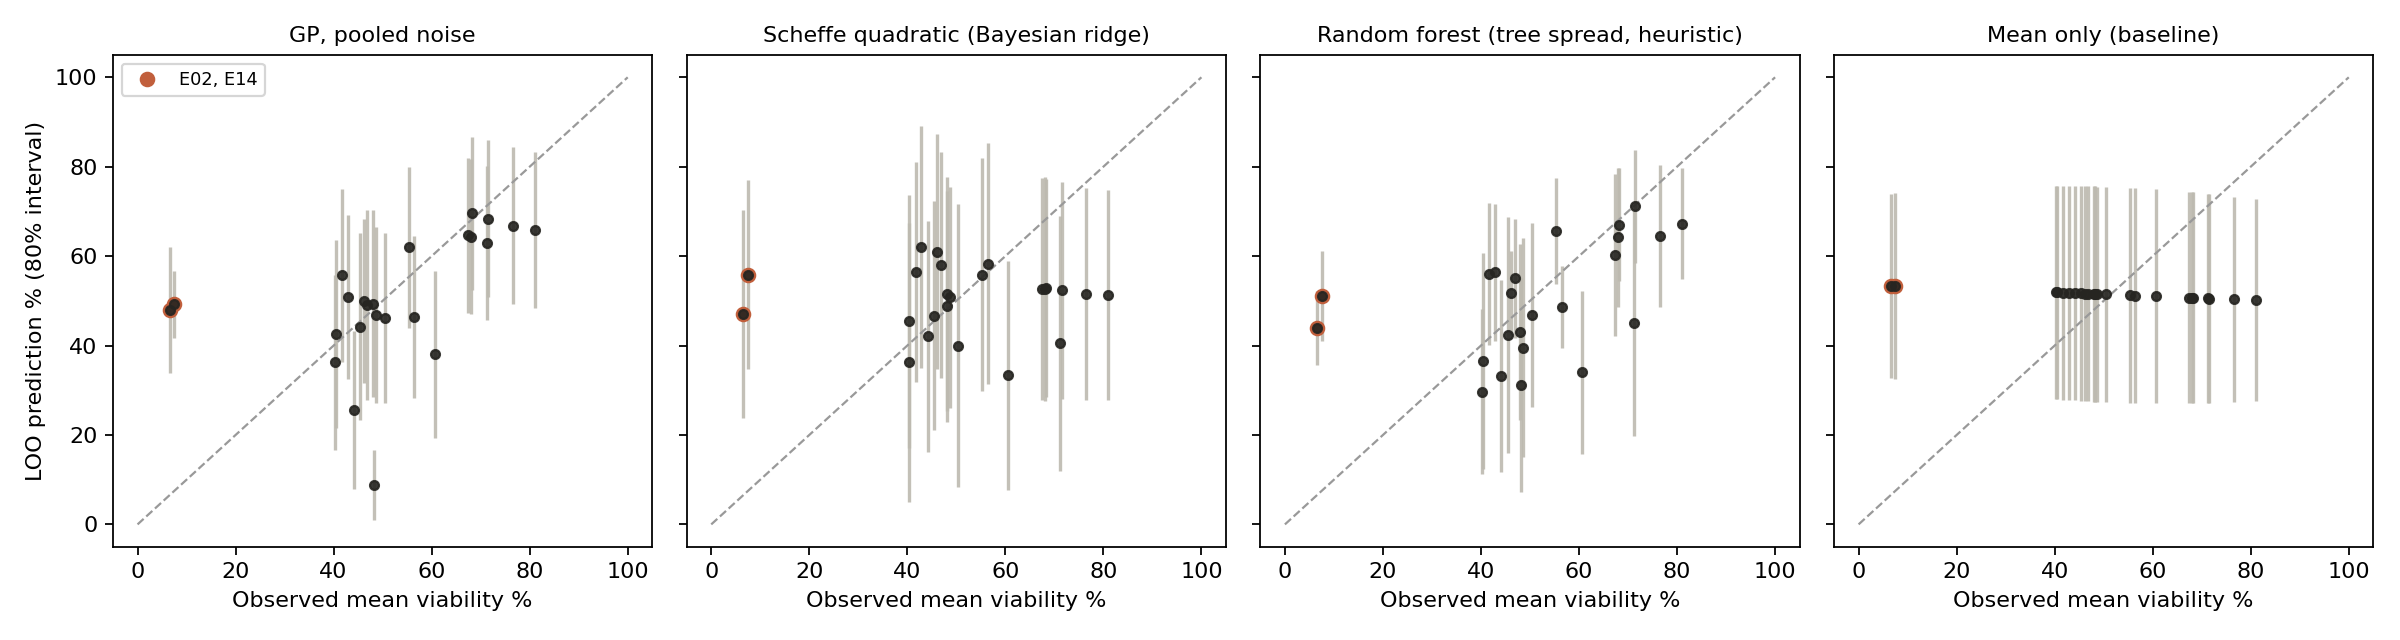

In [5]:
loo = pd.read_csv(ROOT / 'reports/tables/model_loo.csv')
display(loo[loo.training == 'all 24'][['model', 'rmse', 'spearman', 'coverage_80', 'nlpd']])
fwd = pd.read_csv(ROOT / 'reports/tables/model_forward_round.csv')
display(fwd[['model', 'test_round', 'rmse', 'bias', 'spearman', 'coverage_80']])
fig('06_loo_parity.png', 900)

## 5. The fitted GP

The main model, refitted here. Note the length scales: DMEM sits at its 0.1 floor and RPMI-10 and AR5 at the 10.0 ceiling, so the model treats RPMI-10 and AR5 as interchangeable. The batch tests that assumption.

In [6]:
import numpy as np
from compare_models import GP
from design_space import load_data
ids, rounds, X, y, sem = load_data()
gp = GP('pooled', restarts=10).fit(X, y, sem)
print('kernel:', gp.m.kernel_)
print('noise SD on a recipe mean:', round(float(np.sqrt(gp.noise_new) * gp.ys), 2), 'viability points')

kernel: 0.737**2 * Matern(length_scale=[0.1, 10, 0.326, 10], nu=2.5) + WhiteKernel(noise_level=0.433)
noise SD on a recipe mean: 11.83 viability points


## 6. Policy simulation

30 paired campaigns against two smooth synthetic truths at two noise levels. Illustrative only: it compares policies, it does not validate the four blends.

In [7]:
pd.read_csv(ROOT / 'reports/tables/policy_simulation_summary.csv')

,truth,noise,policy,median_regret_18_runs,q25,q75,median_paired_diff_vs_random,seeds_better_than_random
0,GP fit to all 24,low (SEM 4.97),Random (feasible),7.82,1.58,16.25,0.00,0/30
1,GP fit to all 24,low (SEM 4.97),GP greedy (exploit only),10.30,4.26,17.26,0.00,13/30
2,GP fit to all 24,low (SEM 4.97),"GP-UCB, kappa 2 (batch)",2.92,1.28,5.45,-2.12,21/30
3,GP fit to all 24,low (SEM 4.97),GP-EI (batch),2.89,1.49,7.73,-1.22,21/30
4,GP fit to all 24,low (SEM 4.97),Four-role policy (deployed),1.56,1.11,3.53,-5.36,23/30
5,GP fit to all 24,high (fitted 11.83),Random (feasible),7.82,1.58,16.25,0.00,0/30
6,GP fit to all 24,high (fitted 11.83),GP greedy (exploit only),10.16,3.80,18.88,0.03,9/30
7,GP fit to all 24,high (fitted 11.83),"GP-UCB, kappa 2 (batch)",4.57,2.30,16.40,0.00,14/30
8,GP fit to all 24,high (fitted 11.83),GP-EI (batch),4.54,2.89,17.05,0.00,12/30
9,GP fit to all 24,high (fitted 11.83),Four-role policy (deployed),3.20,1.22,12.83,-0.95,19/30


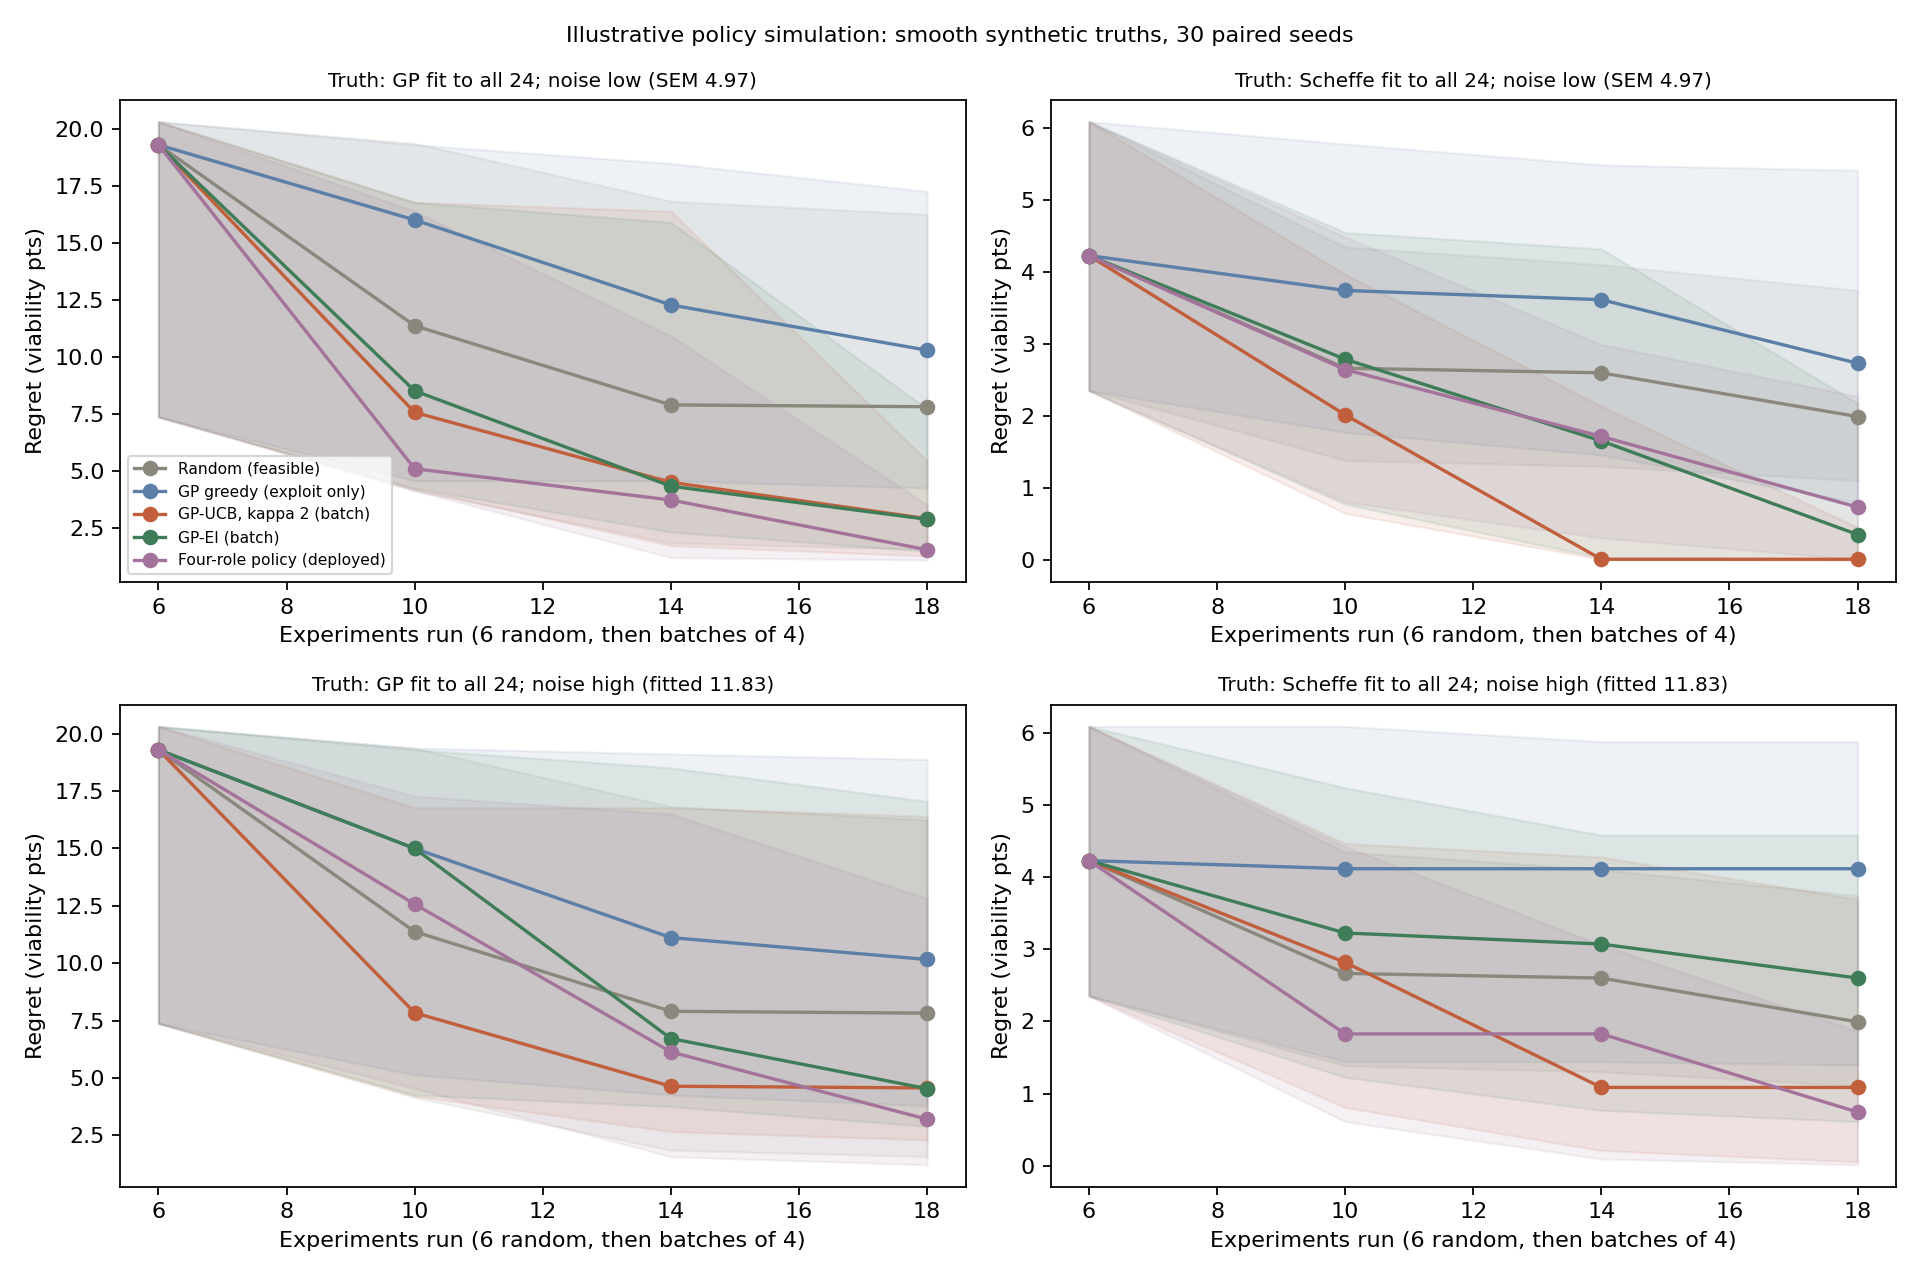

In [8]:
fig('07_policy_simulation.png', 900)

## 7. The recommendation

One slot per role, chosen in sequence. After each pick the GP conditions on a pending result, so the exploring slots look elsewhere.

,slot,role,dmem_pct,rpmi_10_pct,xvivo_pct,ar5_pct,cost_eur_per_litre_base,within_ceiling_scenarios,predicted_viability_pct,measured_mean_80pct_low,measured_mean_80pct_high,prob_true_viability_above_e19
0,1,Exploit,44,26,19,11,177.69,8/9,70.2,53.6,86.8,0.54
1,2,Cheaper alternative,43,56,1,0,173.92,7/9,65.9,49.2,82.6,0.27
2,3,Explore,37,33,30,0,176.82,8/9,60.1,41.1,79.2,0.12
3,4,Expected improvement,45,21,27,7,178.31,8/9,69.1,51.5,86.7,0.38


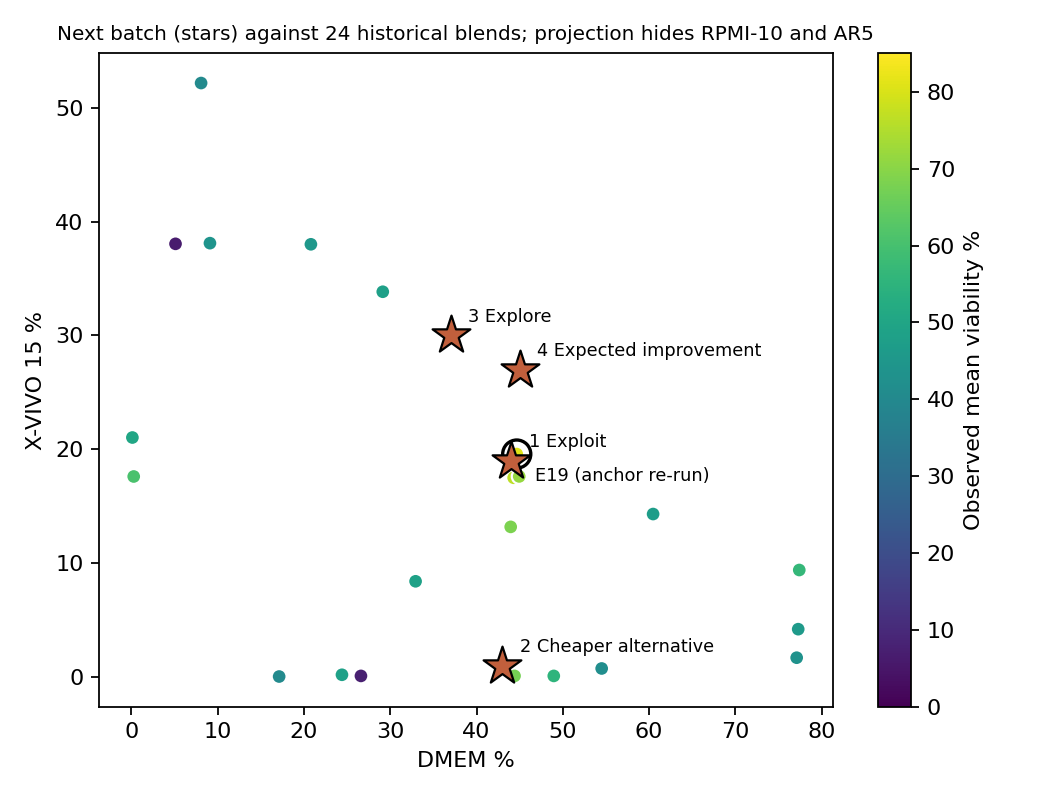

In [9]:
rec = pd.read_csv(ROOT / 'outputs/next_experiments.csv')
display(rec[['slot', 'role', 'dmem_pct', 'rpmi_10_pct', 'xvivo_pct', 'ar5_pct', 'cost_eur_per_litre_base',
             'within_ceiling_scenarios', 'predicted_viability_pct', 'measured_mean_80pct_low',
             'measured_mean_80pct_high', 'prob_true_viability_above_e19']])
fig('08_next_batch.png', 600)

## 8. How stable are the picks?

Each row reruns the full selection with one change. Cells are the volume (%) separating the rerun's pick from the main pick.

In [10]:
display(pd.read_csv(ROOT / 'reports/tables/batch_stability.csv').iloc[:, :5])
pd.read_csv(ROOT / 'reports/tables/batch_threshold_stress.csv').iloc[:, :5]

,variant,slot_1_shift_pct,slot_2_shift_pct,slot_3_shift_pct,slot_4_shift_pct
0,gp_sem_noise,26.0,23.0,31.0,12.0
1,gp_ls_floor_0.05,1.0,1.0,11.0,5.0
2,gp_ls_floor_0.2,7.0,1.0,27.0,7.0
3,gp_ls_upper_3,0.0,0.0,0.0,2.0
4,gp_without_e02,7.0,0.0,4.0,9.0
5,gp_without_e14,7.0,1.0,40.0,7.0
6,price_fbs_x0.5_ar5_x1.0,0.0,25.0,16.0,1.0
7,price_fbs_x0.5_ar5_x1.5,0.0,25.0,24.0,5.0
8,price_fbs_x0.5_ar5_x2.02,0.0,25.0,21.0,7.0
9,price_fbs_x1.0_ar5_x1.5,0.0,25.0,21.0,7.0


,setting,slot_1_shift_pct,slot_2_shift_pct,slot_3_shift_pct,slot_4_shift_pct
0,cheap_discount_0%,0.0,25.0,1.0,2.0
1,cheap_discount_5%,0.0,44.0,1.0,1.0
2,min_gap_3%,2.0,0.0,0.0,0.0
3,min_gap_8%,4.0,0.0,1.0,0.0
4,min_scenarios_5_of_9,0.0,0.0,0.0,0.0
5,min_scenarios_7_of_9,0.0,0.0,1.0,0.0
6,single_media_allowed,0.0,0.0,0.0,0.0


## 9. The plate

Five formulations, four randomised wells each, interior wells only. The screen passes a blend that is no more than 5 points below the same-plate E19 at equal or lower cost. A pass goes to a confirmation run of about 20 wells per arm over at least two independent preparations.

In [11]:
display(pd.read_csv(ROOT / 'outputs/plate_formulations.csv'))
pd.read_csv(ROOT / 'outputs/plate_layout.csv').head(8)

,position,role,dmem_ml_per_100ml,rpmi_10_ml_per_100ml,xvivo_ml_per_100ml,ar5_ml_per_100ml
0,slot 1,Exploit,44.0,26.0,19.0,11.0
1,slot 2,Cheaper alternative,43.0,56.0,1.0,0.0
2,slot 3,Explore,37.0,33.0,30.0,0.0
3,slot 4,Expected improvement,45.0,21.0,27.0,7.0
4,anchor,PBMC-E19 re-run (historical 81.0%),44.6,20.1,19.6,15.7


,well,position,role,replicate
0,B3,slot 3,Explore,4
1,B4,anchor,PBMC-E19 re-run (historical 81.0%),3
2,B6,slot 4,Expected improvement,4
3,B7,slot 2,Cheaper alternative,1
4,B11,slot 3,Explore,3
5,C5,slot 1,Exploit,1
6,C7,slot 1,Exploit,4
7,D4,slot 2,Cheaper alternative,3
